In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Data Load

In [73]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\Mini Project\Predict Customer Clicked Ads Classification by Using Machine Learning\Tahap01\Clicked_Ads_Dataset.csv")

# Renaming columns
df = df.rename(columns={'Male': 'Sex'})

In [74]:
df.sample(10).head(10)

,Unnamed: 0,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Sex,Timestamp,Clicked on Ad,city,province,category
685,685,76.27,27,"420,578,620.00",226.69,Laki-Laki,6/18/2016 1:42,No,Cimahi,Jawa Barat,Travel
370,370,58.60,50,"317,803,500.00",113.70,Perempuan,1/28/2016 7:10,Yes,Bandung,Jawa Barat,Furniture
553,553,44.73,35,"387,218,790.00",127.56,Laki-Laki,1/27/2016 18:25,Yes,Cimahi,Jawa Barat,Travel
830,830,42.51,30,"383,289,970.00",144.77,Laki-Laki,1/15/2016 19:45,Yes,Jakarta Utara,Daerah Khusus Ibukota Jakarta,Food
818,818,81.98,34,"472,027,430.00",212.88,Perempuan,6/4/2016 9:25,No,Denpasar,Bali,Otomotif
846,846,55.74,37,"182,916,510.00",124.34,Laki-Laki,2/11/2016 16:45,Yes,Jakarta Timur,Daerah Khusus Ibukota Jakarta,Otomotif
734,734,56.57,26,"395,049,200.00",131.98,Perempuan,1/23/2016 13:14,Yes,Bekasi,Jawa Barat,Electronic
709,709,77.80,57,"305,962,160.00",152.94,Perempuan,2/14/2016 14:38,Yes,Surabaya,Jawa Timur,Fashion
120,120,86.19,31,"403,685,870.00",210.26,Laki-Laki,5/8/2016 12:51,No,Pakanbaru,Riau,Otomotif
705,705,78.84,26,"396,156,600.00",217.66,Laki-Laki,6/29/2016 7:20,No,Samarinda,Kalimantan Timur,Electronic


# Statistical Analysis

## Num & Cat

In [29]:
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))

num_cols=["Daily Time Spent on Site", "Age", "Area Income", "Daily Internet Usage"]
print("\n=== NUMERICAL ===")
display(df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])


cat_cols=["Sex", "city", "province", "category", "Clicked on Ad"]
print("\n=== CATEGORICAL ===")

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


=== NUMERICAL ===


,mean,std,min,50%,max
Daily Time Spent on Site,64.93,15.84,32.60,68.11,91.43
Age,36.01,8.79,19.00,35.00,61.00
Area Income,"384,864,670.64","94,079,989.57","97,975,500.00","399,068,320.00","556,393,600.00"
Daily Internet Usage,179.86,43.87,104.78,182.65,267.01



=== CATEGORICAL ===

--- Sex ---
Sex
Perempuan    518
Laki-Laki    479
NaN            3
Name: count, dtype: int64

--- city ---
city
Surabaya             64
Bandung              64
Jakarta Timur        63
Jakarta Selatan      61
Jakarta Barat        57
Bekasi               56
Medan                48
Jakarta Utara        45
Palembang            42
Semarang             41
Batam                34
Makassar             33
Tangerang Selatan    33
Tangerang            32
Depok                30
Bandar Lampung       29
Bogor                28
Jakarta Pusat        27
Malang               26
Banjarmasin          23
Pakanbaru            23
Denpasar             21
Padang               19
Balikpapan           18
Cimahi               17
Samarinda            16
Tasikmalaya          15
Pontianak            12
Surakarta            12
Serang               11
Name: count, dtype: int64

--- province ---
province
Daerah Khusus Ibukota Jakarta    253
Jawa Barat                       210
Jawa Timur         

## Univariate Analysis

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_14100\1600430577.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sex", data=df, ax=axes[1, 1], palette='Set2')
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_14100\1600430577.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Clicked on Ad", data=df, ax=axes[1, 2], palette='Set1')


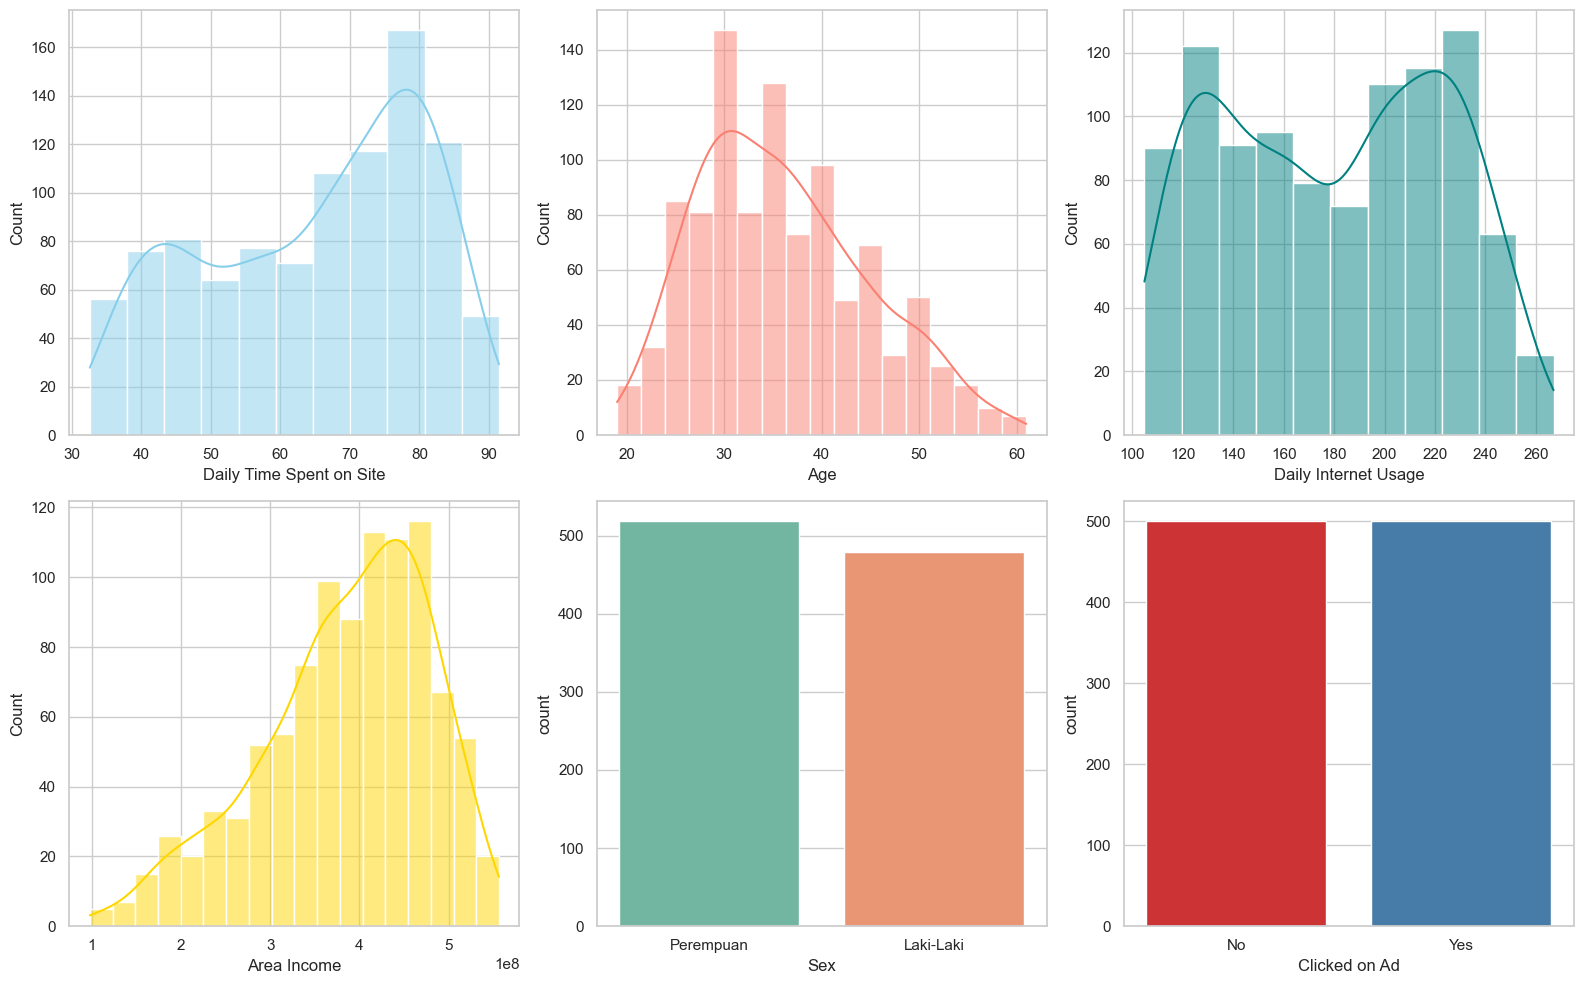

In [30]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Numerical Plots (Histograms with KDE)
sns.histplot(df["Daily Time Spent on Site"], kde=True, ax=axes[0, 0], color='skyblue')
sns.histplot(df["Age"], kde=True, ax=axes[0, 1], color='salmon')
sns.histplot(df["Daily Internet Usage"], kde=True, ax=axes[0, 2], color='teal')
sns.histplot(df["Area Income"], kde=True, ax=axes[1, 0], color='gold')

# Categorical Distributions
sns.countplot(x="Sex", data=df, ax=axes[1, 1], palette='Set2')
sns.countplot(x="Clicked on Ad", data=df, ax=axes[1, 2], palette='Set1')

plt.tight_layout()
plt.show()

## Bivariate

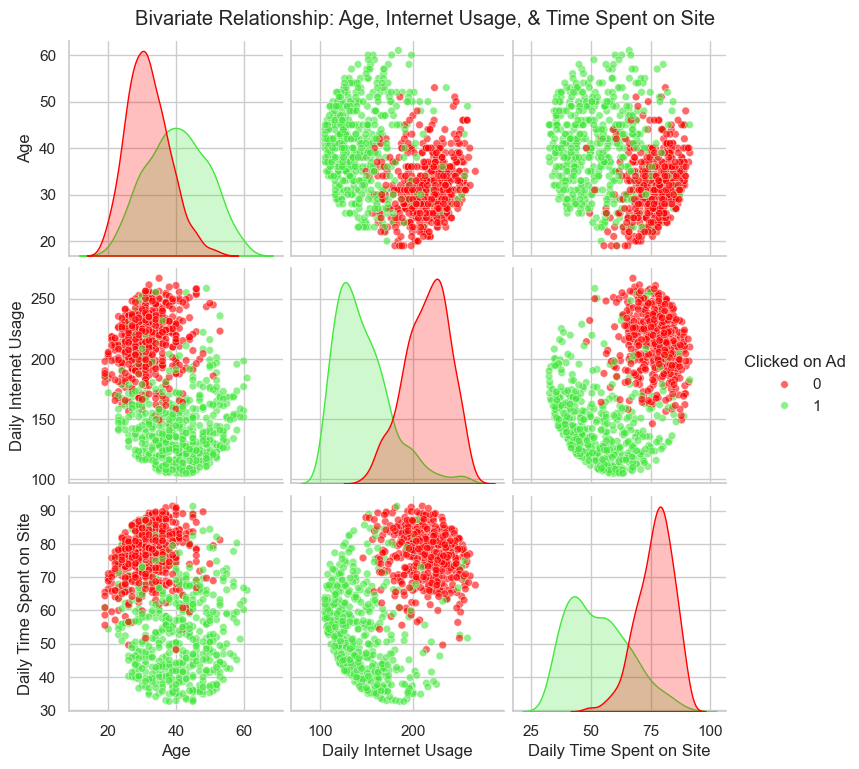

In [31]:
target_features = ['Age', 'Daily Internet Usage', 'Daily Time Spent on Site', 'Clicked on Ad']

df['Clicked on Ad'] = df['Clicked on Ad'].map({'No': 0, 'Yes': 1})

sns.pairplot(
    df[target_features], 
    hue='Clicked on Ad', 
    palette={0: "#ff0000", 1: "#42e73c"}, # 0: Green (No Click), 1: Red (Clicked)
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Bivariate Relationship: Age, Internet Usage, & Time Spent on Site', y=1.02)
plt.show()

## Multivariate

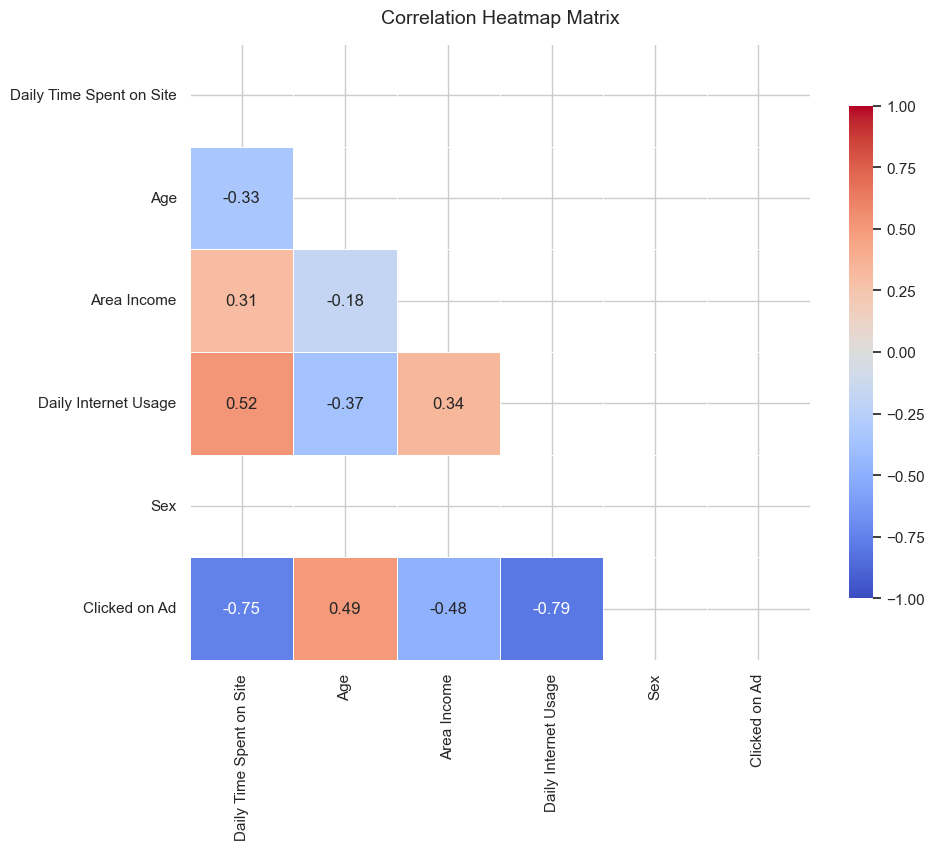

In [32]:
# Convert gender strings to binary (1 for Male, 0 for Female/Perempuan)
df['Sex'] = df['Sex'].map({'Laki-laki': 1, 'Perempuan': 0})

# Selecting numerical columns including target
corr_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Sex', 'Clicked on Ad']

# Compute Pearson correlation matrix
corr_matrix = df[corr_cols].corr()

# Removes duplicate mirror information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap Matrix', fontsize=14, pad=15)
plt.show()

# Data Cleaning

## Missing&Duplicated

In [75]:
#Missing
print("=== MISSING / NULL VALUES ===")
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
display(null_summary[null_summary['Null Count'] > 0] if df.isnull().sum().sum() > 0 else "No missing values found!")


#Duplicate
print("\n=== DUPLICATED DATA ===")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

=== MISSING / NULL VALUES ===


,Null Count,Null Percentage (%)
Daily Time Spent on Site,13,1.30
Area Income,13,1.30
Daily Internet Usage,11,1.10
Sex,3,0.30



=== DUPLICATED DATA ===
Total duplicate rows: 0


## Missing Handling

In [76]:
df = df.dropna(subset=['Sex']).reset_index(drop=True)

df["Daily Time Spent on Site"] = df["Daily Time Spent on Site"].fillna(
    df["Daily Time Spent on Site"].mean()
)

df["Daily Internet Usage"] = df["Daily Internet Usage"].fillna(
    df["Daily Internet Usage"].mean()
)

df["Area Income"] = df["Area Income"].fillna(df["Area Income"].median())

# Datetime Extraction

In [77]:
# Convert to datetime object
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract temporal features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Drop original Timestamp column
df = df.drop(columns=['Timestamp'])

print("=== EXTRACTED DATETIME FEATURES ===")
display(df[['Hour', 'Day', 'Month', 'DayOfWeek', 'Is_Weekend']].head())

=== EXTRACTED DATETIME FEATURES ===


,Hour,Day,Month,DayOfWeek,Is_Weekend
0,0,27,3,6,1
1,1,4,4,0,0
2,20,13,3,6,1
3,2,10,1,6,1
4,3,3,6,4,0


# Feature Encoding (get_dummies)

In [78]:
# Select categorical columns with potential high cardinality
high_cardinality_cols = ['city', 'province', 'category']

# Limit each column to Top 10 most frequent values, label rest as 'Other'
for col in high_cardinality_cols:
    # Find top 10 categories
    top_10 = df[col].value_counts().nlargest(10).index
    
    # Replace non-top 10 values with 'Other'
    df[col] = df[col].apply(lambda x: x if x in top_10 else 'Other')

print("=== VERIFY TOP 10 CARDINALITY ===")
for col in high_cardinality_cols:
    print(f"Unique categories in '{col}': {df[col].nunique()} (Top 10 + 'Other')")

# Now perform One-Hot Encoding safely
df_encoded = pd.get_dummies(
    df, 
    columns=high_cardinality_cols, 
    drop_first=True,  # Avoids dummy variable trap
    dtype=int
)

print(f"\nFinal encoded dataset shape: {df_encoded.shape}")

=== VERIFY TOP 10 CARDINALITY ===
Unique categories in 'city': 11 (Top 10 + 'Other')
Unique categories in 'province': 11 (Top 10 + 'Other')
Unique categories in 'category': 10 (Top 10 + 'Other')

Final encoded dataset shape: (997, 41)


# Train-Test Split

In [79]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
X = df_encoded.drop(columns=['Clicked on Ad'])
y = df_encoded['Clicked on Ad']

# 2. Perform Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Maintains target ratio (0s vs 1s) in both splits
)

# 3. Display Split Statistics
print("=== DATASET SPLIT SUMMARY ===")
print(f"X_train shape : {X_train.shape} (80%)")
print(f"X_test shape  : {X_test.shape} (20%)")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

print("\nTarget Class Balance in Training Set:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTarget Class Balance in Testing Set:")
print(y_test.value_counts(normalize=True).round(3))

=== DATASET SPLIT SUMMARY ===
X_train shape : (797, 40) (80%)
X_test shape  : (200, 40) (20%)
y_train shape : (797,)
y_test shape  : (200,)

Target Class Balance in Training Set:
Clicked on Ad
Yes   0.50
No    0.50
Name: proportion, dtype: float64

Target Class Balance in Testing Set:
Clicked on Ad
Yes   0.50
No    0.50
Name: proportion, dtype: float64


# COBA_COBA/TEST_DRIVE

In [80]:
df

,Unnamed: 0,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Sex,Clicked on Ad,city,province,category,Hour,Day,Month,DayOfWeek,Is_Weekend
0,0,68.95,35,"432,837,300.00",256.09,Perempuan,No,Jakarta Timur,Daerah Khusus Ibukota Jakarta,Furniture,0,27,3,6,1
1,1,80.23,31,"479,092,950.00",193.77,Laki-Laki,No,Other,Other,Food,1,4,4,0,0
2,2,69.47,26,"418,501,580.00",236.50,Perempuan,No,Surabaya,Jawa Timur,Electronic,20,13,3,6,1
3,3,74.15,29,"383,643,260.00",245.89,Laki-Laki,No,Other,Kepulauan Riau,House,2,10,1,6,1
4,4,68.37,35,"517,229,930.00",225.58,Perempuan,No,Medan,Sumatra Utara,Finance,3,3,6,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,995,72.97,30,"499,691,990.00",208.58,Laki-Laki,Yes,Semarang,Jawa Tengah,Finance,21,11,2,3,0
993,996,51.30,45,"474,475,190.00",134.42,Laki-Laki,Yes,Other,Other,Electronic,2,22,4,4,0
994,997,64.90,51,"296,910,040.00",120.37,Laki-Laki,Yes,Other,Kalimantan Timur,Travel,17,1,2,0,0
995,998,55.55,19,"293,445,530.00",187.95,Perempuan,No,Other,Banten,Bank,2,24,3,3,0


Plot saved successfully.


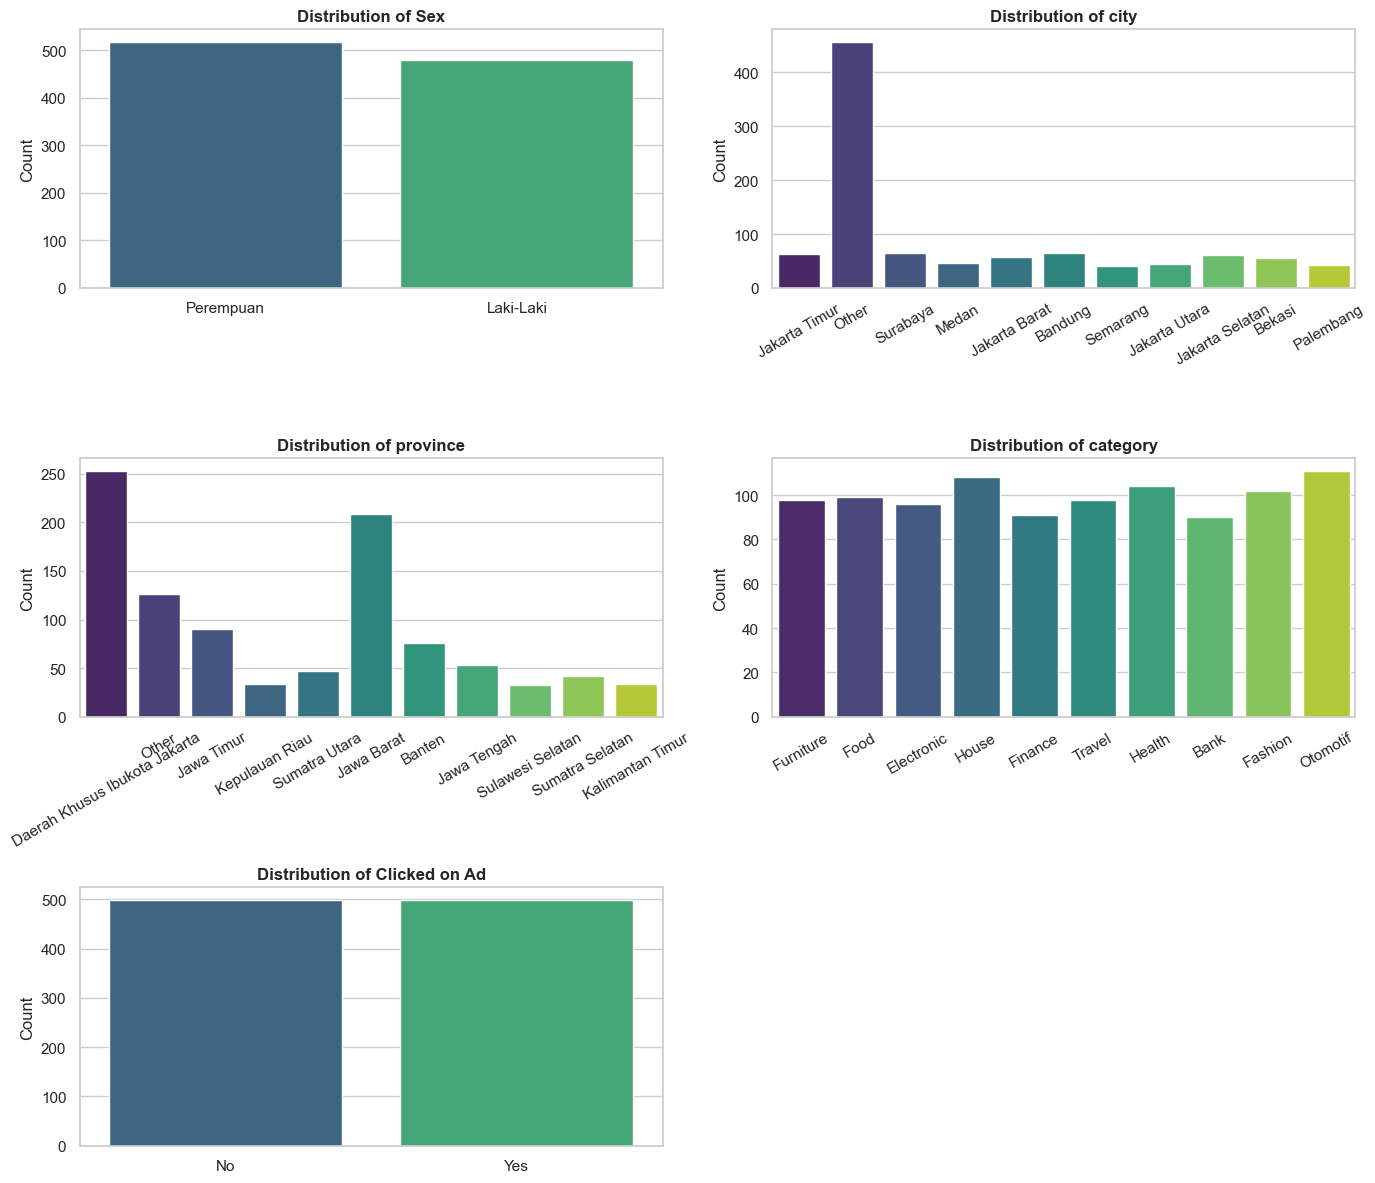

In [81]:
cat_cols = ["Sex", "city", "province", "category", "Clicked on Ad"]

# Set up figure grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=30 if df[col].nunique() > 3 else 0)

# Remove empty subplot (since 5 features in 3x2 grid leaves 1 extra)
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("categorical_distributions.png")
print("Plot saved successfully.")

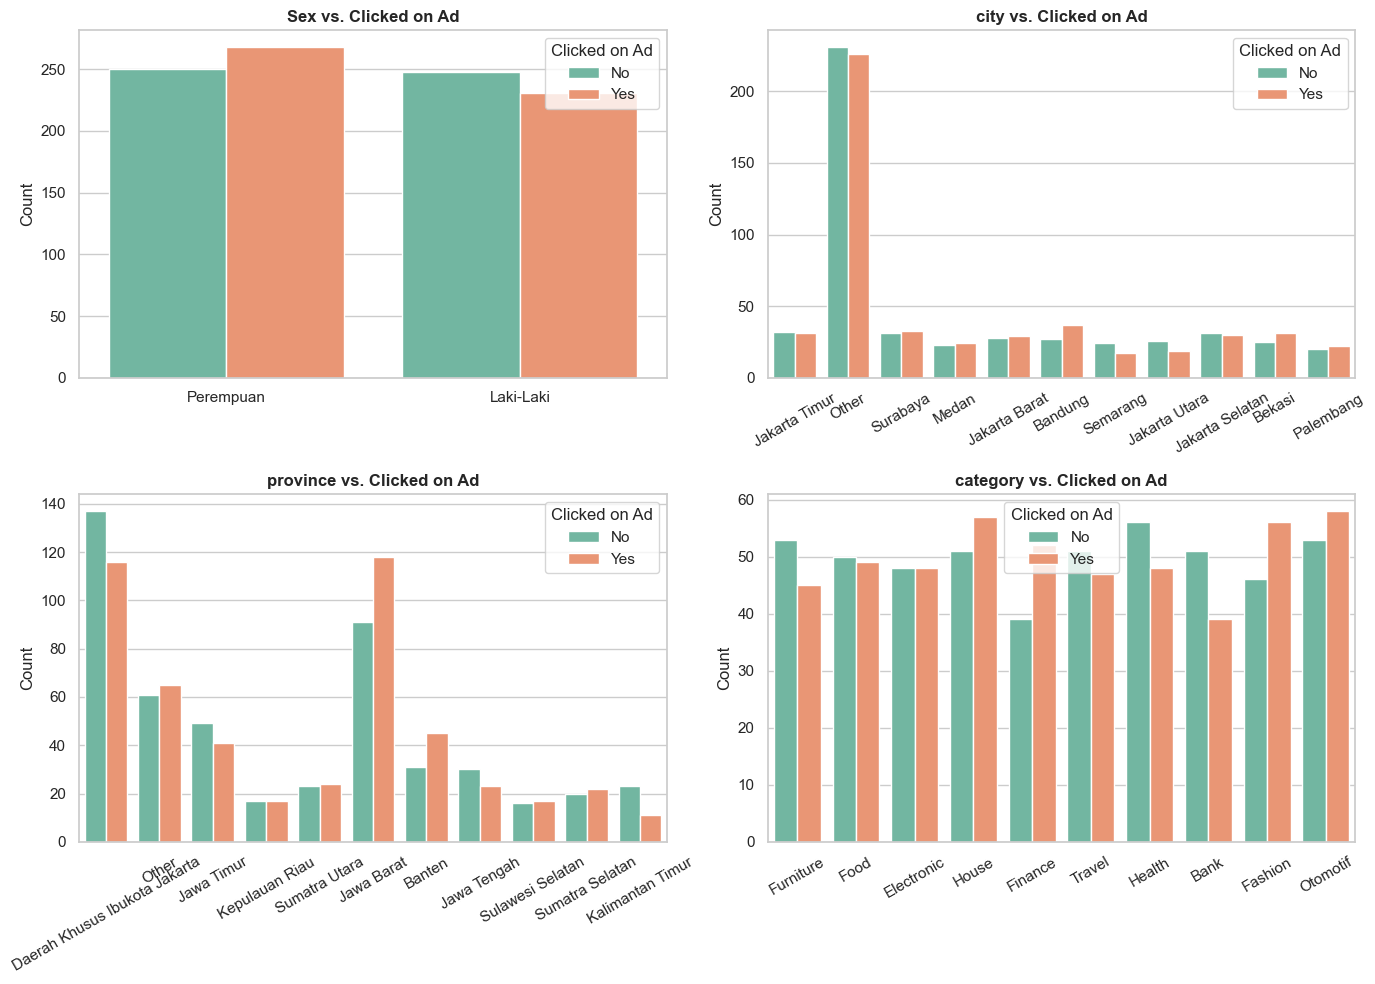

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to compare against 'Clicked on Ad'
cat_features = ["Sex", "city", "province", "category"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue="Clicked on Ad", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs. Clicked on Ad", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    if df[col].nunique() > 3:
        axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Saved successfully!


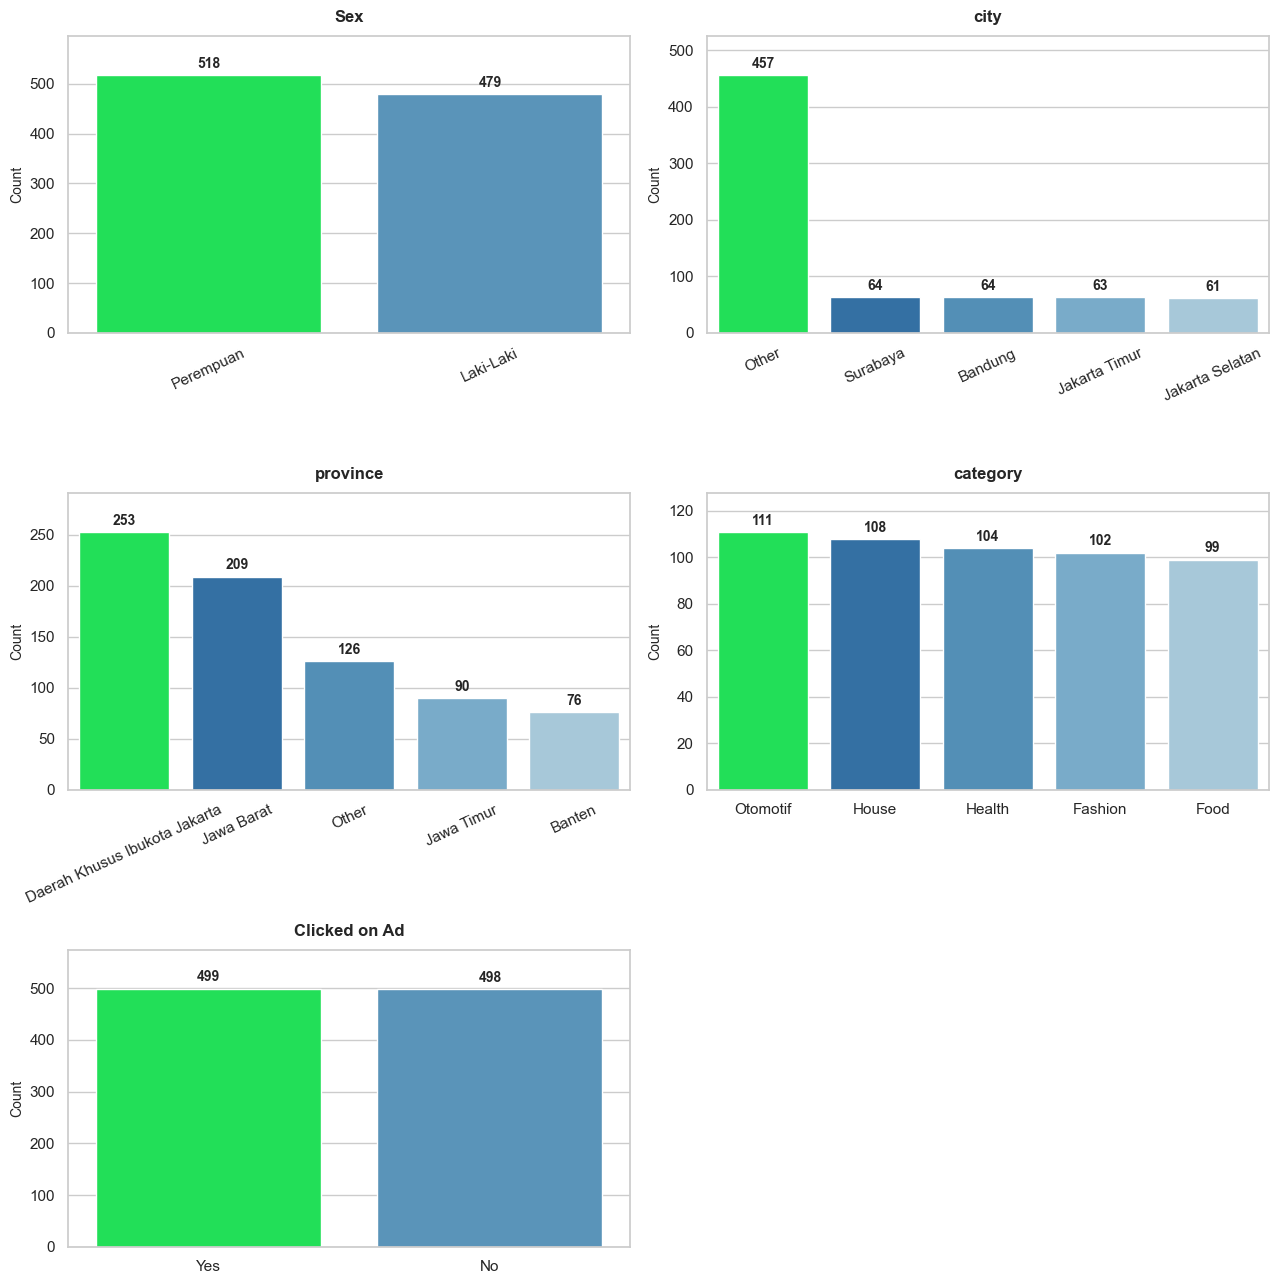

In [83]:

cat_cols = ["Sex", "city", "province", "category", "Clicked on Ad"]

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 13))
axes = axes.flatten()

# Color definitions
highlight_color = "#02FF4A"  # Distinct red for highest bar

for i, col in enumerate(cat_cols):
    # Top 5 counts in descending order
    top_counts = df[col].value_counts().head(5)
    
    n_bars = len(top_counts)
    
    # Generate sequential shades of blue/teal for remaining bars
    # Highest bar (index 0) gets highlight color; index 1..n get decreasing shades
    shades = sns.color_palette("Blues_r", n_colors=n_bars + 2)[1:n_bars] if n_bars > 1 else []
    bar_colors = [highlight_color] + list(shades)
    
    # Plot using sns.barplot
    ax = axes[i]
    sns.barplot(
        x=top_counts.index.astype(str),
        y=top_counts.values,
        ax=ax,
        palette=bar_colors,
        hue=top_counts.index.astype(str)
    )
    
    if ax.get_legend():
        ax.get_legend().remove()
    
    ax.set_title(f"{col}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=10)
    
    # Expand y-limit slightly so labels fit nicely above bars
    ax.set_ylim(0, max(top_counts.values) * 1.15)
    
    # Add count amount above each bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                xytext=(0, 3), textcoords='offset points'
            )
            
    if any(len(str(x)) > 8 for x in top_counts.index):
        ax.tick_params(axis='x', rotation=25)

# Remove unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("categorical_top5_custom.png", dpi=150)
print("Saved successfully!")